# 03 - Etapa C: Modelo MLP (Multilayer Perceptron)

Implementa la clasificación de marcha en diplejía con la red **MLP** propuesta en el artículo de *Ferrari et al. (2019)* (Sección 4).

### Características del Pipeline:
1. **Input:** Vector de **1620 features** por trial (extraídos en Etapa B mediante FFT).
2. **Split Paciente a Paciente (75/25):** División *patient-wise* para evitar *data leakage* entre train y test.
3. **Data Augmentation:** Duplicación de la Forma 1 en entrenamiento (Tabla 3).
4. **Arquitectura:** Red profunda de 5 capas (256 -> 128 -> 64 -> Dropout 0.2 -> 32 -> 4 clases) (Figura 1).
5. **Métricas a Nivel Paciente:** Evaluación de **Top-1** y **Top-2** Accuracy por forma clínica (Tabla 7).

In [1]:
import sys, os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from src.models import (
    patient_wise_split, augment_form1, DiplegiaMLP, evaluate_patient_level
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de cómputo: {device}')

Dispositivo de cómputo: cpu


## 1. Carga de Features y Partitioning Patient-Wise (§3.2 Task 5)

In [2]:
data_path = '../data/features/mlp_features.npz'
data = np.load(data_path)

X       = data['X']        # (1123, 1620)
y       = data['y']        # (1123,)
subject = data['subject']  # (1123,)

print(f'Dataset MLP cargado: {X.shape[0]} trials, {X.shape[1]} features')
print(f'Pacientes únicos totales: {len(np.unique(subject))}')

# Patient-wise split (75% train / 25% test)
train_idx, test_idx = patient_wise_split(X, y, subject, train_ratio=0.75, seed=42)

X_train_raw, y_train_raw, subj_train_raw = X[train_idx], y[train_idx], subject[train_idx]
X_test, y_test, subj_test              = X[test_idx], y[test_idx], subject[test_idx]

# Data Augmentation en Form 1 para Train (Tabla 3)
X_train, y_train, subj_train = augment_form1(X_train_raw, y_train_raw, subj_train_raw)

print(f'\nPartitioning Patient-Wise:')
print(f'  Train raw: {len(X_train_raw)} trials ({len(np.unique(subj_train_raw))} pacientes)')
print(f'  Train augmented (Form 1 x2): {len(X_train)} trials')
print(f'  Test: {len(X_test)} trials ({len(np.unique(subj_test))} pacientes)')

print('\nDistribución por clase en Test:')
for f in range(4):
    cnt = np.sum(y_test == f)
    sub_cnt = len(np.unique(subj_test[y_test == f]))
    print(f'  Form {f+1}: {cnt} trials ({sub_cnt} pacientes)')

Dataset MLP cargado: 1123 trials, 1620 features
Pacientes únicos totales: 178

Partitioning Patient-Wise:
  Train raw: 835 trials (134 pacientes)
  Train augmented (Form 1 x2): 881 trials
  Test: 288 trials (44 pacientes)

Distribución por clase en Test:
  Form 1: 17 trials (3 pacientes)
  Form 2: 76 trials (13 pacientes)
  Form 3: 53 trials (8 pacientes)
  Form 4: 142 trials (20 pacientes)


## 2. Entrenamiento de la Red MLP (§4)

Entrenamos con optimizador Adam (learning rate = $0.001$) y pérdida `CrossEntropyLoss`.

In [3]:
# Normalización Z-score de features
mean = np.mean(X_train, axis=0, keepdims=True)
std  = np.std(X_train, axis=0, keepdims=True) + 1e-8

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std

# DataLoaders
train_ds = TensorDataset(torch.tensor(X_train_norm, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Instanciar modelo
model_mlp = DiplegiaMLP(input_dim=1620, num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)

# Entrenar
epochs = 80
history = {'train_loss': [], 'train_acc': []}

for epoch in range(1, epochs + 1):
    model_mlp.train()
    total_loss, correct, total = 0.0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model_mlp(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * bx.size(0)
        correct += (out.argmax(dim=-1) == by).sum().item()
        total += bx.size(0)
        
    ep_loss = total_loss / total
    ep_acc  = correct / total
    history['train_loss'].append(ep_loss)
    history['train_acc'].append(ep_acc)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{epochs:02d} | Loss: {ep_loss:.4f} | Train Acc: {ep_acc:.2%}')

Epoch 01/80 | Loss: 1.2164 | Train Acc: 39.50%
Epoch 10/80 | Loss: 0.0106 | Train Acc: 99.89%
Epoch 20/80 | Loss: 0.0045 | Train Acc: 99.89%
Epoch 30/80 | Loss: 0.0003 | Train Acc: 100.00%
Epoch 40/80 | Loss: 0.0001 | Train Acc: 100.00%
Epoch 50/80 | Loss: 0.0001 | Train Acc: 100.00%
Epoch 60/80 | Loss: 0.0002 | Train Acc: 100.00%
Epoch 70/80 | Loss: 0.0002 | Train Acc: 100.00%
Epoch 80/80 | Loss: 0.0001 | Train Acc: 100.00%


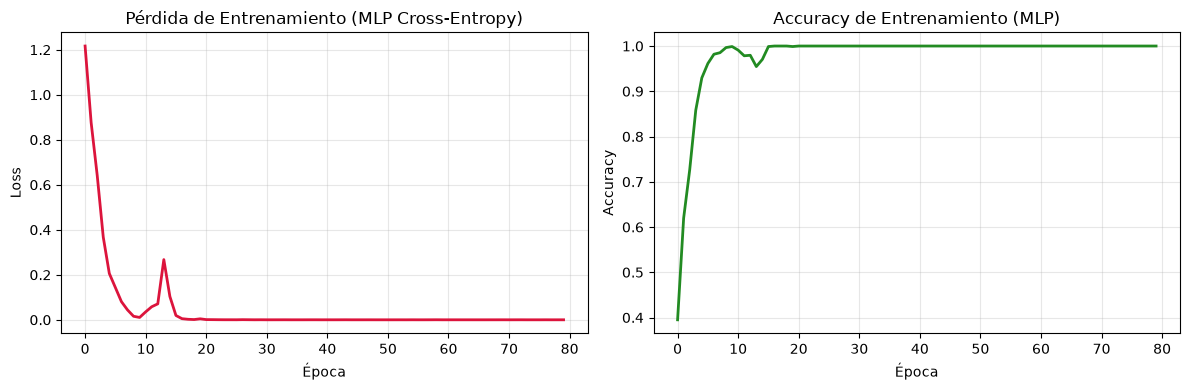

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], color='crimson', lw=2)
ax[0].set_title('Pérdida de Entrenamiento (MLP Cross-Entropy)')
ax[0].set_xlabel('Época'); ax[0].set_ylabel('Loss'); ax[0].grid(True, alpha=0.3)

ax[1].plot(history['train_acc'], color='forestgreen', lw=2)
ax[1].set_title('Accuracy de Entrenamiento (MLP)')
ax[1].set_xlabel('Época'); ax[1].set_ylabel('Accuracy'); ax[1].grid(True, alpha=0.3)
plt.tight_layout()

## 3. Evaluación Paciente a Paciente (Tabla 7 del Paper)

In [5]:
res_mlp = evaluate_patient_level(model_mlp, X_test_norm, y_test, subj_test, device=device)

print(f'=== RESULTADOS EVALUACIÓN A NIVEL PACIENTE (MLP) ===')
print(f'Pacientes en Test: {res_mlp["num_patients"]}')
print(f'Overall Top-1 Accuracy: {res_mlp["overall_t1"]:.1%}')
print(f'Overall Top-2 Accuracy: {res_mlp["overall_t2"]:.1%}')

# Comparación detallada por Forma con Tabla 7
paper_t1 = {0: 0.750, 1: 0.846, 2: 0.111, 3: 0.600}
paper_t2 = {0: 0.750, 1: 1.000, 2: 0.333, 3: 0.900}

print(f'\nComparación por Forma Clínica (Test Set):')
print(f'{"Forma":<8} {"Nuestros T1":>12} {"Paper T1":>10} | {"Nuestros T2":>12} {"Paper T2":>10}')
print('-' * 60)
for f in range(4):
    print(f'Form {f+1:<3} {res_mlp["form_t1"][f]:>12.1%} {paper_t1[f]:>10.1%} | ' 
          f'{res_mlp["form_t2"][f]:>12.1%} {paper_t2[f]:>10.1%}')
print('-' * 60)
print(f'GLOBAL   {res_mlp["overall_t1"]:>12.1%} {0.587:>10.1%} | '
      f'{res_mlp["overall_t2"]:>12.1%} {0.804:>10.1%}')

=== RESULTADOS EVALUACIÓN A NIVEL PACIENTE (MLP) ===
Pacientes en Test: 44
Overall Top-1 Accuracy: 40.9%
Overall Top-2 Accuracy: 75.0%

Comparación por Forma Clínica (Test Set):
Forma     Nuestros T1   Paper T1 |  Nuestros T2   Paper T2
------------------------------------------------------------
Form 1          66.7%      75.0% |       100.0%      75.0%
Form 2          15.4%      84.6% |        53.8%     100.0%
Form 3           0.0%      11.1% |        87.5%      33.3%
Form 4          70.0%      60.0% |        80.0%      90.0%
------------------------------------------------------------
GLOBAL          40.9%      58.7% |        75.0%      80.4%


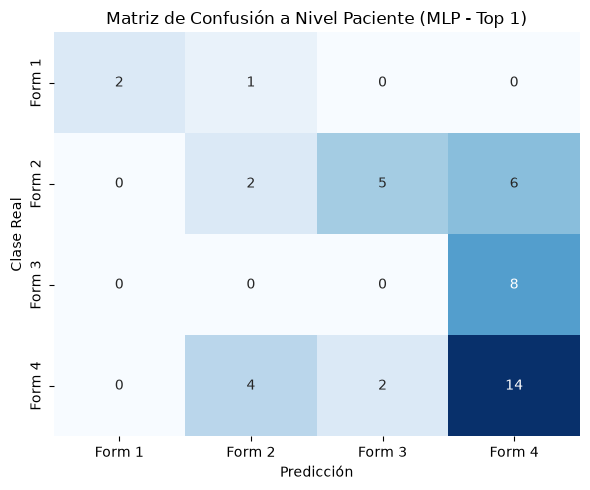

In [8]:
# Visualizar Matriz de Confusión a Nivel Paciente
import seaborn as sns
cm = res_mlp['cm']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Form 1', 'Form 2', 'Form 3', 'Form 4'],
            yticklabels=['Form 1', 'Form 2', 'Form 3', 'Form 4'])
ax.set_title('Matriz de Confusión a Nivel Paciente (MLP - Top 1)')
ax.set_xlabel('Predicción'); ax.set_ylabel('Clase Real')
plt.tight_layout()